In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.environ['PYSPARK_PYTHON']='python'

In [3]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
import pyspark.sql.functions as F


In [4]:
spark = SparkSession.builder.appName("LR-pyspark").getOrCreate()

25/12/08 10:07:59 WARN Utils: Your hostname, Biplovs-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.12.38.68 instead (on interface en0)
25/12/08 10:07:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/08 10:08:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/08 10:08:00 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/12/08 10:08:00 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [5]:
data =[(3.5, 5.8),
      (6.7, 9.7),
      (9.8, 11.2),
      (14.12, 16.8),
      (19.0, 25.0)]

In [6]:
df = spark.createDataFrame(data, schema=["x", "y"])
df.show()

+-----+----+
|    x|   y|
+-----+----+
|  3.5| 5.8|
|  6.7| 9.7|
|  9.8|11.2|
|14.12|16.8|
| 19.0|25.0|
+-----+----+



In [7]:
#Vector assembler
assembler = VectorAssembler(inputCols= ['x'], outputCol ="features")
df_features = assembler.transform(df).select("features", 'x', 'y')

In [8]:
df_features.show()


+--------+-----+----+
|features|    x|   y|
+--------+-----+----+
|   [3.5]|  3.5| 5.8|
|   [6.7]|  6.7| 9.7|
|   [9.8]|  9.8|11.2|
| [14.12]|14.12|16.8|
|  [19.0]| 19.0|25.0|
+--------+-----+----+



In [9]:
lr = LinearRegression(featuresCol='features', labelCol = 'y')
model = lr.fit(df_features)

25/12/08 10:08:08 WARN Instrumentation: [0da934de] regParam is zero, which might cause numerical instability and overfitting.
25/12/08 10:08:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/08 10:08:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/12/08 10:08:09 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [10]:
intercept = model.intercept
# intercept.show()
print(intercept)

0.9175227629277612


In [11]:
slope = float(model.coefficients[0])
print(slope)

1.203169920658155


In [12]:
r2 = model.summary.r2
print(r2)

0.9731279081654046


In [13]:
from pyspark.sql import functions as F

pred = (
    model.transform(df_features)
         .withColumnRenamed("Prediction", "y_hat")
         .withColumn("residual", F.col('y') - F.col('y_hat'))
)


In [14]:
pred.select('x', 'y', 'y_hat', 'residual').show()

+-----+----+------------------+------------------+
|    x|   y|             y_hat|          residual|
+-----+----+------------------+------------------+
|  3.5| 5.8| 5.128617485231303|0.6713825147686965|
|  6.7| 9.7| 8.978761231337401|0.7212387686625981|
|  9.8|11.2|12.708587985377681|-1.508587985377682|
|14.12|16.8| 17.90628204262091|-1.106282042620908|
| 19.0|25.0|23.777751255432705|1.2222487445672954|
+-----+----+------------------+------------------+



25/12/08 10:08:11 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


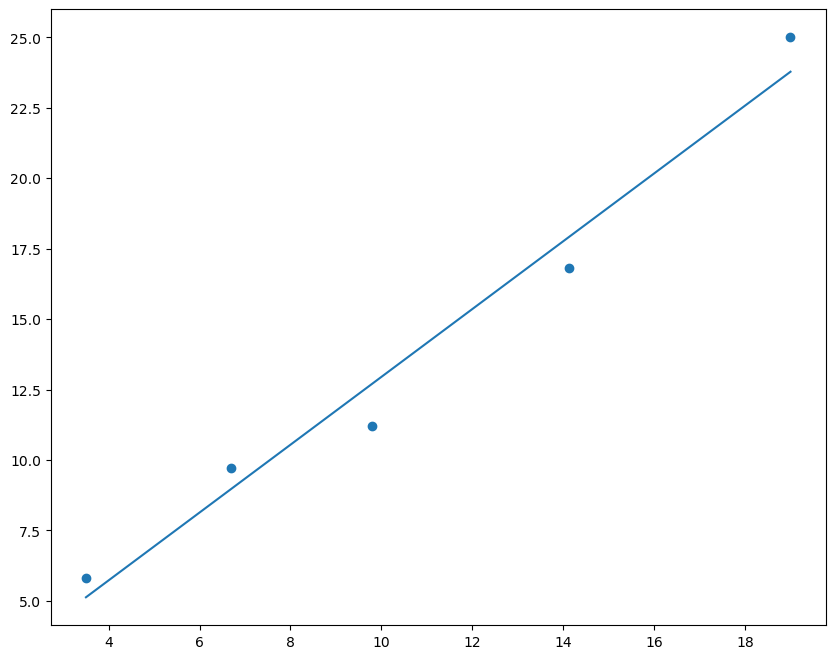

In [15]:
pdf = pred.select('x', 'y', 'y_hat', 'residual').toPandas()
x_vals = pdf['x'].values
y_vals = pdf['y'].values

x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
y_line = intercept + slope * x_line

plt.figure(figsize=(10, 8))
plt.scatter(x_vals, y_vals)
plt.plot(x_line, y_line)
plt.show()